In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## Settings

In [17]:
target_col = "gap_ev"         
feature_set = "nmr_stats"        # "an14", "an14_full_initial", "nmr_stats", "NMF", "c_bins_10", "c_bins_5", "an14_full_with_c_bins_10", "an14_full_with_c_bins_5"
seed = 42
train_frac, val_frac, test_frac = 0.70, 0.15, 0.15

In [18]:
df = pd.read_pickle("/Users/jacknugent/Downloads/alberts_nmr_qchem_merged.pkl")

In [19]:
df.columns

Index(['h_nmr_peaks', 'h_nmr_spectra', 'molecular_formula', 'c_nmr_peaks',
       'c_nmr_spectra', 'canonical_smiles', 'hex_id', 'Filename', 'name',
       'homo_ev',
       ...
       'nmr_dict_code_25', 'nmr_dict_code_26', 'nmr_dict_code_27',
       'nmr_dict_code_28', 'nmr_dict_code_29', 'nmr_dict_code_30',
       'nmr_dict_code_31', 'nmr_h_reconstruction_error',
       'nmr_c_reconstruction_error', 'nmr_total_reconstruction_error'],
      dtype='string', length=136)

In [20]:
# An et al. (2014) Eq. 6: 10 selected integration bins + 3 broadness terms
an14_cols = [
    "an14_x0.5", "an14_x1", "an14_x1.5", "an14_x2",
    "an14_x4.5", "an14_x5", "an14_x5.5",
    "an14_x6.5", "an14_x7", "an14_x7.5",
    "an14_b1", "an14_b2", "an14_b3",
]

# Full 24-bin grid (0.5 ppm wide, 0–12 ppm) + broadness + total nH
an14_full_cols = [
    f"an14_x{e}" for e in
    ["0.5", "1", "1.5", "2", "2.5", "3", "3.5", "4",
     "4.5", "5", "5.5", "6", "6.5", "7", "7.5", "8",
     "8.5", "9", "9.5", "10", "10.5", "11", "11.5", "12"]
] + ["an14_b1", "an14_b2", "an14_b3", "an14_total_nH"]

# Summary statistics from NMR peaks
nmr_stats_cols = [
    "num_delta_13C", "num_delta_1H",
    "max_delta_13C", "max_delta_1H",
    "mean_delta_13C",
    "skew_delta_13C", "skew_delta_1H",
    "kurt_delta_13C",
]

nmf_cols = [f"nmr_dict_code_{i:02d}" for i in range(32)] + \
           ["nmr_h_reconstruction_error", "nmr_c_reconstruction_error", "nmr_total_reconstruction_error"]

# 10 ppm bins for 13C NMR
c_bins_10_cols = [
    f"c_x{e}" for e in range(10, 230, 10)
] + ["c_b1", "c_b2", "c_b3", "c_total_nC"]

# 5 ppm bins for 13C NMR
c_bins_5_cols = [
    f"c_x{e}" for e in range(5, 225, 5)
] + ["c_b1", "c_b2", "c_b3", "c_total_nC"]

feature_sets = {
    "an14":              an14_cols,
    "an14_full_initial": an14_full_cols,
    "nmr_stats":         nmr_stats_cols,
    "NMF":               nmf_cols,
    "c_bins_10":                  c_bins_10_cols,
    "c_bins_5":                   c_bins_5_cols,
    "an14_full_with_c_bins_10":   an14_full_cols + c_bins_10_cols,
    "an14_full_with_c_bins_5":    an14_full_cols + c_bins_5_cols,
}


feature_cols = feature_sets[feature_set]
assert all(c in df.columns for c in feature_cols), "Some feature columns are missing from the data"
print(f"Using '{feature_set}' → {len(feature_cols)} features")


Using 'nmr_stats' → 8 features


# train val test

In [21]:
model_df = df.dropna(subset=[target_col] + feature_cols)
print(f"{len(model_df)} / {len(df)} rows have no NaNs in target + features")

X = model_df[feature_cols].astype(float)
y = model_df[target_col].astype(float)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=test_frac, random_state=seed,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_frac / (train_frac + val_frac),
    random_state=seed,
)

print(f"Train {len(X_train)}  |  Val {len(X_val)}  |  Test {len(X_test)}")

9599 / 9599 rows have no NaNs in target + features
Train 6719  |  Val 1440  |  Test 1440


## metrics

In [22]:
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "rmse":  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae":   float(mean_absolute_error(y_true, y_pred)),
        "medae": float(median_absolute_error(y_true, y_pred)),
        "r2":    float(r2_score(y_true, y_pred)),
    }

## hyperparameter search


In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

search_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10_000)),  # placeholder
])

pls_components = [c for c in [2, 3, 5, 8] if c <= len(feature_cols)]

param_grid = [
    {"model": [LinearRegression()]},

    {"model": [PLSRegression()],
     "model__n_components": pls_components},

    {"model": [ElasticNet(max_iter=10_000, random_state=seed)],
     "model__alpha": [1e-3, 1e-2, 0.1],
     "model__l1_ratio": [0.2, 0.5, 0.8]},

    {"model": [KNeighborsRegressor(n_jobs=1)],
     "model__n_neighbors": [3, 5, 7, 11, 15],
     "model__weights": ["uniform", "distance"],
     "model__p": [1, 2]},

    {"model": [RandomForestRegressor(random_state=seed, n_jobs=1)],
     "model__n_estimators": [300],
     "model__max_depth": [4, 6, 8],
     "model__min_samples_leaf": [1, 3]},

    {"model": [HistGradientBoostingRegressor(random_state=seed)],
     "model__learning_rate": [0.03, 0.05, 0.07],
     "model__max_depth": [2, 3, 4],
     "model__max_iter": [150, 200],
     "model__min_samples_leaf": [10, 15, 20],
     "model__l2_regularization": [0.1, 0.5, 1.0, 2.0]},
]

n_combos = sum(int(np.prod([len(v) for v in g.values()])) for g in param_grid)
print(f"{n_combos} param combos × {cv.get_n_splits()} folds = {n_combos * cv.get_n_splits()} fits")

grid_search = GridSearchCV(
    search_pipe, param_grid,
    cv=cv, scoring="neg_root_mean_squared_error",
    n_jobs=-1, refit=True,
)
grid_search.fit(X_trainval, y_trainval)

best_pipe = grid_search.best_estimator_
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")
print(f"Best params:  {grid_search.best_params_}")

256 param combos × 5 folds = 1280 fits
Best CV RMSE: 0.6126
Best params:  {'model': HistGradientBoostingRegressor(random_state=42), 'model__l2_regularization': 1.0, 'model__learning_rate': 0.07, 'model__max_depth': 4, 'model__max_iter': 200, 'model__min_samples_leaf': 20}


## Best model per type
Extract the best estimator of each model class from the grid-search results,
refit each on the full train/val set, and collect them for test-set evaluation.

In [24]:
from sklearn.base import clone

cv_res = pd.DataFrame(grid_search.cv_results_)

# derive model class name for every param combo
cv_res["model_type"] = cv_res["param_model"].apply(lambda m: type(m).__name__)

# for each model type keep the row with the best mean_test_score
best_per_type = (
    cv_res
    .sort_values("rank_test_score")
    .drop_duplicates(subset="model_type", keep="first")
)

# refit a pipeline for each best-per-type on the full trainval set
best_pipes = {}  # model_type -> {pipeline, cv_rmse, params}
for _, row in best_per_type.iterrows():
    params = row["params"]
    pipe_clone = clone(search_pipe).set_params(**params)
    pipe_clone.fit(X_trainval, y_trainval)
    model_name = row["model_type"]
    best_pipes[model_name] = {
        "pipeline": pipe_clone,
        "cv_rmse": -row["mean_test_score"],
        "params": params,
    }

print(f"Saved best pipeline for {len(best_pipes)} model types:")
for name, info in sorted(best_pipes.items(), key=lambda x: x[1]['cv_rmse']):
    print(f"  {name:35s}  CV RMSE = {info['cv_rmse']:.4f}")


Saved best pipeline for 6 model types:
  HistGradientBoostingRegressor        CV RMSE = 0.6126
  RandomForestRegressor                CV RMSE = 0.6250
  KNeighborsRegressor                  CV RMSE = 0.6382
  ElasticNet                           CV RMSE = 0.6849
  PLSRegression                        CV RMSE = 0.6849
  LinearRegression                     CV RMSE = 0.6849


## Test set – all model types

In [25]:
overall_best_type = type(grid_search.best_params_["model"]).__name__

rows = []
for model_name, info in best_pipes.items():
    y_test_pred = info["pipeline"].predict(X_test)
    metrics = regression_metrics(y_test, y_test_pred)
    rows.append({
        "model_type": model_name,
        "cv_rmse": round(info["cv_rmse"], 4),
        "feature_set": feature_set,
        "n_features": len(feature_cols),
        "target": target_col,
        **metrics,
    })

test_comparison = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
test_comparison


,model_type,cv_rmse,feature_set,n_features,target,rmse,mae,medae,r2
0,HistGradientBoostingRegressor,0.6126,nmr_stats,8,gap_ev,0.604713,0.467726,0.378337,0.604846
1,RandomForestRegressor,0.6250,nmr_stats,8,gap_ev,0.616016,0.474430,0.378236,0.589936
2,KNeighborsRegressor,0.6382,nmr_stats,8,gap_ev,0.629662,0.488581,0.398261,0.571566
3,ElasticNet,0.6849,nmr_stats,8,gap_ev,0.669023,0.525201,0.431722,0.516329
4,PLSRegression,0.6849,nmr_stats,8,gap_ev,0.669048,0.525231,0.432174,0.516292
5,LinearRegression,0.6849,nmr_stats,8,gap_ev,0.669048,0.525231,0.432174,0.516292


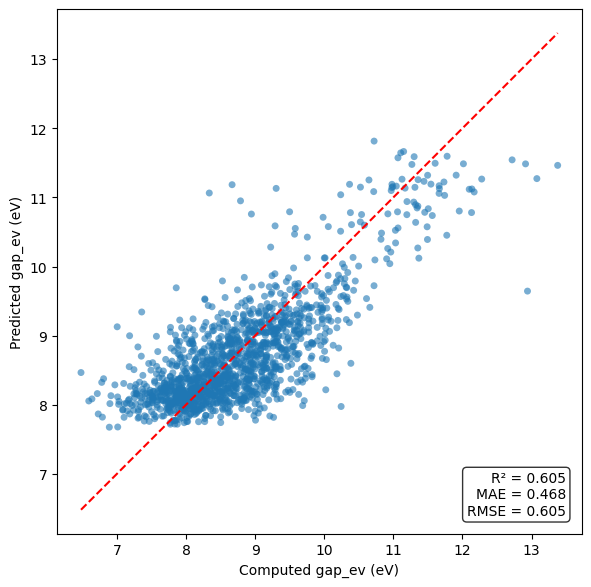

In [26]:
y_test_pred = best_pipe.predict(X_test)
test_metrics = regression_metrics(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_test_pred, alpha=0.6, s=25, edgecolors="none")

lo = min(y_test.min(), y_test_pred.min())
hi = max(y_test.max(), y_test_pred.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)

ax.set_xlabel(f"Computed {target_col} (eV)")
ax.set_ylabel(f"Predicted {target_col} (eV)")
ax.set_aspect("equal", adjustable="box")
ax.text(
    0.97, 0.03,
    f"R² = {test_metrics['r2']:.3f}\n"
    f"MAE = {test_metrics['mae']:.3f}\n"
    f"RMSE = {test_metrics['rmse']:.3f}",
    transform=ax.transAxes, ha="right", va="bottom", 
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.tight_layout()
plt.show()

## SHAP !

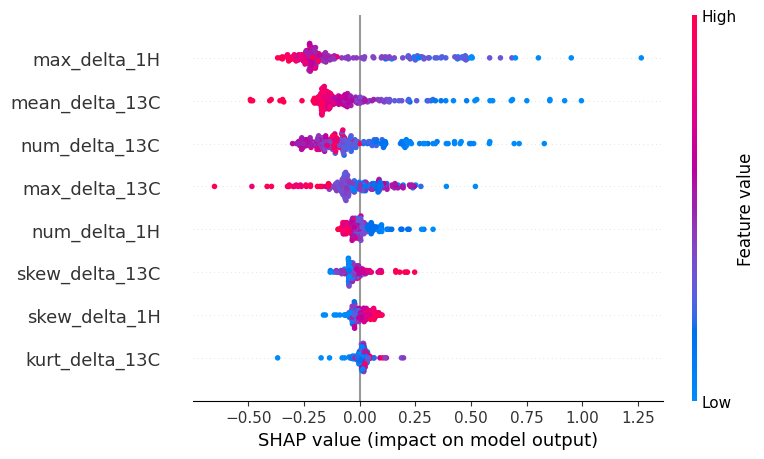

In [27]:
model_step = best_pipe.named_steps["model"]
scaler_step = best_pipe.named_steps["scaler"]

X_bg = pd.DataFrame(
    scaler_step.transform(X_train.sample(200, random_state=seed)),
    columns=feature_cols,
)
X_explain = pd.DataFrame(
    scaler_step.transform(X_test.iloc[:200]),
    columns=feature_cols,
)

if isinstance(
    model_step,
    (RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor),
):
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_explain)
elif isinstance(model_step, KNeighborsRegressor):
    # KernelExplainer is slow; use a small background + explain set for KNN
    bg = shap.sample(X_bg, 50, random_state=seed)
    X_shap = X_explain.iloc[:50]
    explainer = shap.KernelExplainer(model_step.predict, bg)
    shap_values = explainer.shap_values(X_shap)
    X_explain = X_shap
else:
    explainer = shap.LinearExplainer(model_step, X_bg)
    shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, show=False)

In [28]:
from pathlib import Path
from plot_nmf_components import plot_nmf_components

# List of components you want to visualize
components_to_plot = [10,28,30,3]

plot_nmf_components(
    model_path=Path("/Users/jacknugent/Downloads/ids_nmr_1k_dictionary_model.pkl"),
    comp_indices=components_to_plot,
    output_plot=Path("top_shap_nmf_components.png")
)


ModuleNotFoundError: No module named 'plot_nmf_components'

In [ ]:
# mean |SHAP| per feature
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
mean_abs_shap.sort_values(ascending=False)

ValueError: Length of values (35) does not match length of index (28)